# Installation

To install quarto, in your lectures conda environment run:

```conda install -c conda-forge quarto```


Then start jupyter lab:

```jupyter lab```

And create a new jupyter notebook (this one is called notebook.ipynb).

Then open another terminal window, activate your lectures enviornment and laucnh quarto render:

```conda activate lectures```

```quarto preview notebook.ipynb```


This will give you a live preview of your notebook as an html page. You can also specify a different output type - e.g pdf

```quarto preview notebook.ipynb --to pdf```

This will give a live updating PDF document! (But it is slower than html).

To finally output your document you use quarto render:

```quarto render notebook.ipynb --to docx```


# How to use Quarto with Jupyter Lab

This is an example of how you can write a report in a quarto notebook.

All the guidance is taken from the [Quarto JupyterLab documentation][qlab].

[qlab]: https://quarto.org/docs/tools/jupyter-lab.html

All quarto documents require some special header information. In the top sheet of this notebook is a raw notebook cell containing the following:

```
---
title: Matts Quarto Demo
author: Matt Loose
date: 'Nov 12, 2025'
format:
  html:
    code-fold: true
    df-print: paged
---
```

There are a lot of formating options available.

As we go through this notebook and you look at what happens - try changing the code-fold option to false and see what happens.



## Markdown cells.

To write text we need to set the jupyter cell type to markdown. Then we write normal markdown.

## Showing code.

Lets start by including some commands that we might run. All we need to do is to write python code in cells as we would do usually.

Our first step is to import the libraries that we want.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt



Next we want to load the data we are going to process into a dataframe.

In [31]:
# Load the per-base depth file
WGS_df = pd.read_csv("WGS_target_clean_small.txt.gz", sep="\t", header=None, names=["chrom", "pos", "depth"])

Next lets look at our data frame to see what it contains.

In [35]:
WGS_df

,chrom,pos,depth
0,chr21,34777802,39
1,chr21,34777803,41
2,chr21,34777804,40
3,chr21,34777805,41
4,chr21,34777806,41
...,...,...,...
5541357,chrX,153610041,2
5541358,chrX,153610042,2
5541359,chrX,153610043,2
5541360,chrX,153610044,2


Now lets add in some more data:

In [36]:
AD_df = pd.read_csv("AD_target_clean_small.txt.gz", sep="\t", header=None, names=["chrom", "pos", "depth"])

In [37]:
AD_df

,chrom,pos,depth
0,chr21,34777802,46
1,chr21,34777803,46
2,chr21,34777804,46
3,chr21,34777805,46
4,chr21,34777806,45
...,...,...,...
5541357,chrX,153610041,8
5541358,chrX,153610042,8
5541359,chrX,153610043,8
5541360,chrX,153610044,8


Now we want to filter our data, but explain why we are filtering it to our readers. So...

dear reader - we want to filter out chromosome X and Y in our data for reasons that I don't want to explain here - but in a real report I would explain and in detail.

In [38]:
AD_df = AD_df[~AD_df["chrom"].isin(["X", "Y", "chrX", "chrY"])]

In [39]:
WGS_df = WGS_df[~WGS_df["chrom"].isin(["X", "Y", "chrX", "chrY"])]

Now we are going to generate a nice plot:

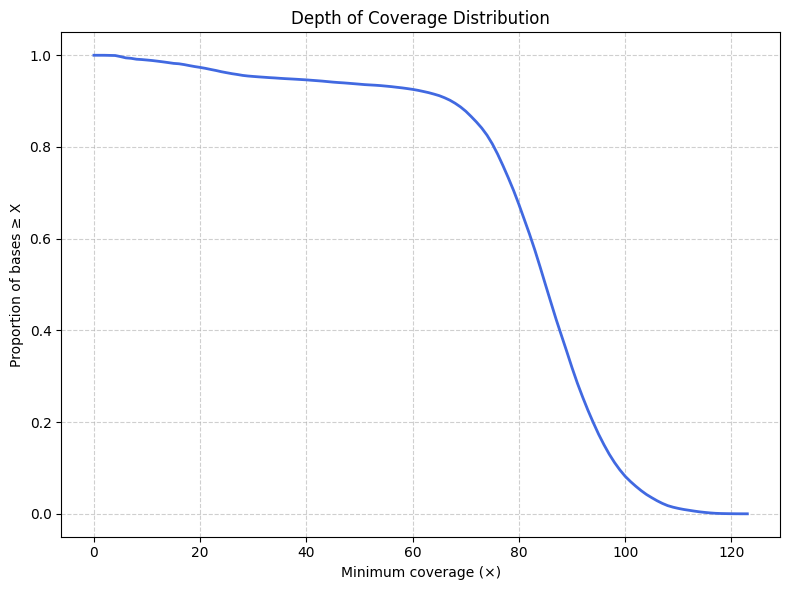

In [40]:
# Calculate the frequency of each coverage depth
depth_counts = AD_df["depth"].value_counts().sort_index()
total_bases = len(AD_df)

# Compute the proportion of bases with coverage >= X
cdf = (depth_counts[::-1].cumsum()[::-1]) / total_bases

# Plot
plt.figure(figsize=(8,6))
plt.plot(cdf.index, cdf.values, color="royalblue", lw=2)
plt.xlabel("Minimum coverage (×)")
plt.ylabel("Proportion of bases ≥ X")
plt.title("Depth of Coverage Distribution")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Magically the plot has appeared - but what if we want to point the reader to it in some way?

To do this, we need to add some specific formatting instructions using yaml to our cells. Lets show this below:


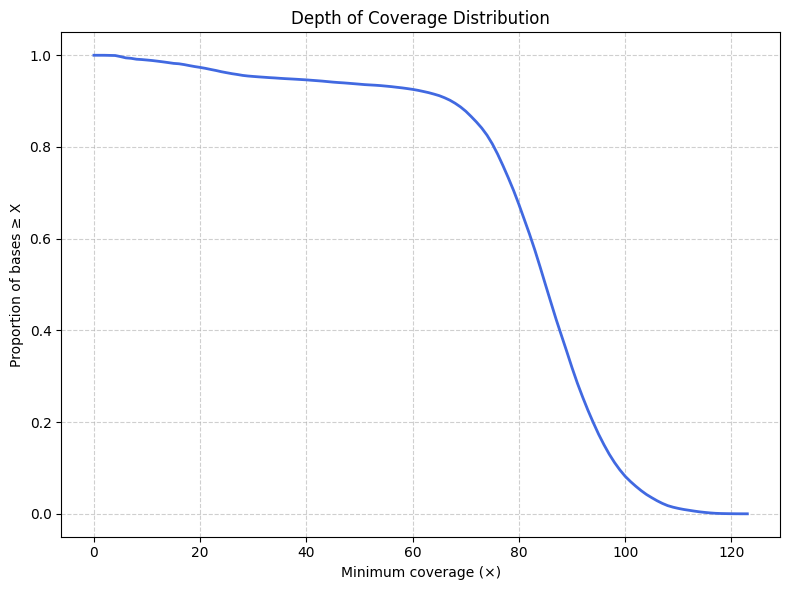

In [41]:
#| label: fig-1
#| fig-cap: A plot showing the proportion of bases covered at a specific depth.


# Calculate the frequency of each coverage depth
depth_counts = AD_df["depth"].value_counts().sort_index()
total_bases = len(AD_df)

# Compute the proportion of bases with coverage >= X
cdf = (depth_counts[::-1].cumsum()[::-1]) / total_bases

# Plot
plt.figure(figsize=(8,6))
plt.plot(cdf.index, cdf.values, color="royalblue", lw=2)
plt.xlabel("Minimum coverage (×)")
plt.ylabel("Proportion of bases ≥ X")
plt.title("Depth of Coverage Distribution")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Note that in the rendered version of the document you don't see any of the yaml instructions, but you do now have a nicely formatted figure with a label and legend. And you can now reference that figure in your text and link to it using @fig-1 .

Now we can have fun with some different examples doing different things and add to our figure. So we are going to add in our second dataset and try manipulating @fig-1 to make @fig-2.

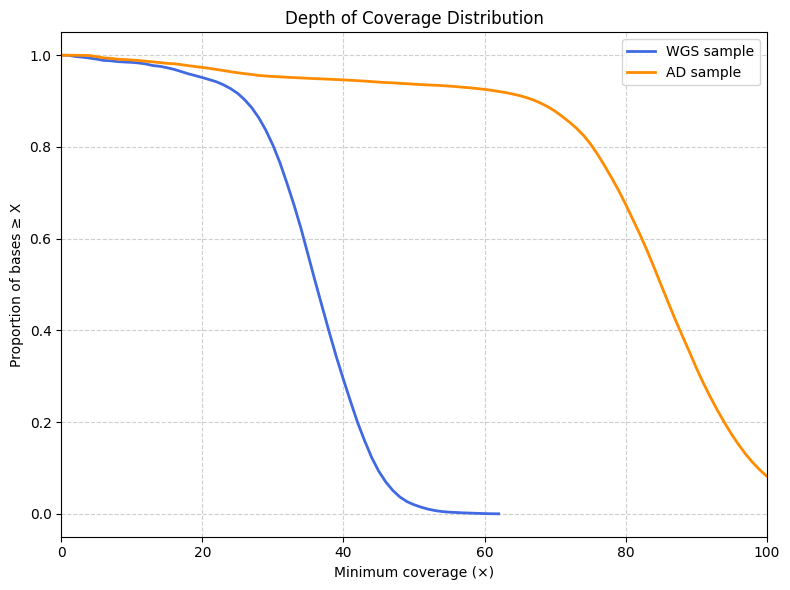

In [42]:
#| label: fig-2
#| fig-cap: A plot showing the proportion of bases covered at a specific depths comparing two samples.


import matplotlib.pyplot as plt
import pandas as pd

def coverage_cdf(df):
    """Return coverage depth (x) and cumulative fraction (y)."""
    depth_counts = df["depth"].value_counts().sort_index()
    total_bases = len(df)
    cdf = (depth_counts[::-1].cumsum()[::-1]) / total_bases
    return cdf.index, cdf.values

# Compute curves
x_wgs, y_wgs = coverage_cdf(WGS_df)
x_ad,  y_ad  = coverage_cdf(AD_df)

# Plot
plt.figure(figsize=(8,6))
plt.plot(x_wgs, y_wgs, color="royalblue", lw=2, label="WGS sample")
plt.plot(x_ad,  y_ad,  color="darkorange", lw=2, label="AD sample")

plt.xlabel("Minimum coverage (×)")
plt.ylabel("Proportion of bases ≥ X")
plt.title("Depth of Coverage Distribution")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

What if we want to make a nice formatted word document? 

We can add some extra code to our raw cell at the start of this document. Try changing it to:

```
---
title: Matts Quarto Demo
author: Matt Loose
date: 'Nov 12, 2025'
format:
  html:
    code-fold: false
    df-print: paged
  docx:
    toc: true
    number-sections: true
    highlight-style: github
---
```

Then save the notebook and see what happens.


There is a lot more you can do, but this is one way to write really well formatted documents that can give you clear reports in different formats.

# Examples 

Here are a few examples of fun things you could try.

::: callout-note
This is a callout block. You can use these to highlight important information.
:::

An example of how to show a dataframe.

In [44]:
import pandas as pd

df = pd.DataFrame({
    "gene": ["TP53", "EGFR", "IDH1", "ATRX"],
    "expression": [12.5, 30.1, 8.8, 15.7]
})
df

,gene,expression
0,TP53,12.5
1,EGFR,30.1
2,IDH1,8.8
3,ATRX,15.7


We can add nice formatting:

In [45]:
df.style.background_gradient(cmap="Blues").set_caption("Expression levels")

,gene,expression
0,TP53,12.500000
1,EGFR,30.100000
2,IDH1,8.800000
3,ATRX,15.700000


We can enable or disable code folding as we wish.

In [47]:

#| code-fold: true
#| echo: true

import numpy as np
np.random.seed(1)
random_vals = np.random.normal(0, 1, 1000)
len(random_vals)

1000

In [48]:
#| code-fold: false
#| echo: true

import numpy as np
np.random.seed(1)
random_vals = np.random.normal(0, 1, 1000)
len(random_vals)

1000

**Figure with caption + cross-reference**

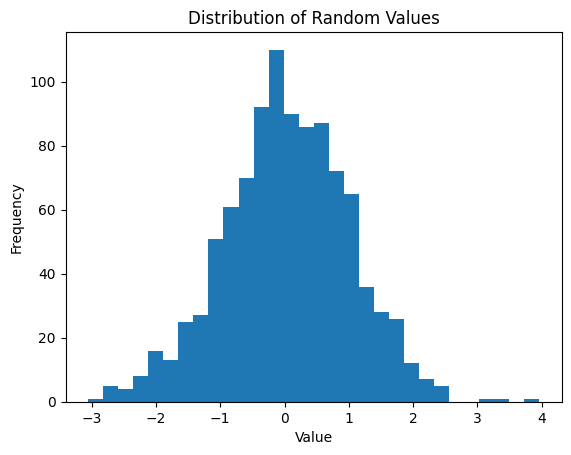

In [50]:
#| label: fig-hist
#| fig-cap: Figure showing a histogram of the simulated values.  
import matplotlib.pyplot as plt

plt.hist(random_vals, bins=30)
plt.title("Distribution of Random Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


This is referenced in the text as @fig-hist.

Note - if you don't correclty reference a figure it will show as an error in the final document. @fig-not-real


What about tables? - we can label them and cite them in the same way @tbl-genes



In [52]:
#| label: tbl-genes
#| tbl-cap: "Gene expression summary"
df

,gene,expression
0,TP53,12.5
1,EGFR,30.1
2,IDH1,8.8
3,ATRX,15.7


Note that this is table 2 - we didn't need to tell the document we already had a table 1.

There's loads more that you can do!